In [1]:
import yaml
import pandas as pd
from pathlib import Path

def load_experiment_results(root_directory):
    """
    Iterates through experiment folders, loads metrics for all resolutions,
    and extracts configuration metadata for later filtering.
    """
    extracted_data = []
    root_path = Path(root_directory)

    # Search for all evaluation files recursively
    for eval_file in root_path.rglob("evaluation_results.yaml"):
        exp_dir = eval_file.parent
        args_file = exp_dir / "args.yaml"
        
        # Load evaluation metrics
        with open(eval_file, 'r') as f:
            eval_data = yaml.safe_load(f)
            
        # Load experiment arguments/config
        args_data = {}
        if args_file.exists():
            with open(args_file, 'r') as f:
                args_data = yaml.safe_load(f)
        
        # Prepare the base record with metadata for filtering
        # 'loss_type' is retrieved from the parent folder (e.g., 'CE' or 'CustomLoss')
        record = {
            'model_name': eval_data['model_info']['model_name'],
            'loss_type': exp_dir.parent.name,
            'fraction': args_data.get('fraction'),
            'epochs': args_data.get('epochs'),
            # Identify if cropped based on args or folder name
            'is_cropped': args_data.get('cropped_dataset', False) or "Cropped" in exp_dir.name
        }
        
        # Iterate through all resolutions available in the yaml (512, 1024, etc.)
        for res_entry in eval_data['evaluation_results']:
            res_w = res_entry['resolution'][0]
            suffix = f"_{res_w}"
            
            # Map results to specific columns (e.g., mean_iou_512, mean_iou_1024)
            res_metrics = res_entry['results']
            record[f'mean_iou{suffix}'] = res_metrics.get('Mean IoU')
            record[f'body_iou{suffix}'] = res_metrics.get('Spacecraft Body')
            record[f'solar_iou{suffix}'] = res_metrics.get('Solar Panels')
            
        extracted_data.append(record)

    return pd.DataFrame(extracted_data)

# --- Execution ---


In [2]:
import matplotlib.pyplot as plt
import numpy as np

def plot_mean_iou(df, title="Mean IoU Comparison"):
    """
    Plots Mean IoU for 512 and 1024 resolutions.
    Adds (Custom) or (CE) suffix to labels based on the dataframe content.
    """
    # 1. Create a copy to avoid modifying your original dataframe
    df_plot = df.copy()

    # 2. Logic to generate the label with suffix
    def create_suffix_label(row):
        suffix = " (CE)" # Default
        
        # Check if 'custom_loss' column is True (cite: 5, 17)
        if 'custom_loss' in row and row['custom_loss'] is True:
            suffix = " (Custom)"
        # Or check if 'loss_type' contains the word 'Custom'
        elif 'loss_type' in row and 'Custom' in str(row['loss_type']):
            suffix = " (Custom)"
            
        return f"{row['model_name']}{suffix}"

    # 3. Create a new column for display names
    df_plot['display_name'] = df_plot.apply(create_suffix_label, axis=1)

    # 4. Sort models by performance (1024 resolution)
    df_plot = df_plot.sort_values(by='mean_iou_1024', ascending=True)

    # 5. Extract data for plotting
    labels = df_plot['display_name'].tolist()
    iou_512 = df_plot['mean_iou_512'].tolist()
    iou_1024 = df_plot['mean_iou_1024'].tolist()

    y = np.arange(len(labels))
    height = 0.35

    # Create figure with enough height for all labels
    fig, ax = plt.subplots(figsize=(14, len(labels) * 0.8))
    
    # Bars for 512x512 (cite: 2, 5, 26)
    rects1 = ax.barh(y - height/2, iou_512, height, label='Res 512', color='#3498db')
    # Bars for 1024x1024 (cite: 2, 5, 26)
    rects2 = ax.barh(y + height/2, iou_1024, height, label='Res 1024', color='#e74c3c')

    # Formatting
    ax.set_xlabel('Mean IoU')
    ax.set_title(title)
    
    # APPLY THE LABELS WITH SUFFIX
    ax.set_yticks(y)
    ax.set_yticklabels(labels)
    
    ax.legend()
    
    # Focus on the high-performance range (adjust if your IoU is lower)
    ax.set_xlim(0.85, 1.0) 

    # Add numeric labels to the bars for precision
    ax.bar_label(rects1, padding=5, fmt='%.4f', fontsize=9)
    ax.bar_label(rects2, padding=5, fmt='%.4f', fontsize=9)

    plt.tight_layout()
    plt.grid(axis='x', linestyle='--', alpha=0.3)
    plt.show()

In [3]:
import matplotlib.pyplot as plt
import numpy as np

def plot_class_iou(df, class_prefix="body_iou", title="Spacecraft Body IoU Comparison"):
    """
    Plots IoU for a specific class (Body or Solar Panels) at 512 and 1024 resolutions.
    
    Args:
        df: The dataframe from load_experiment_results.
        class_prefix: "body_iou" or "solar_iou" (based on your loading function columns).
        title: Title of the chart.
    """
    df_plot = df.copy()

    # Dynamic suffix logic (Custom vs CE)
    def create_suffix_label(row):
        suffix = " (CE)"
        if 'custom_loss' in row and row['custom_loss'] is True:
            suffix = " (Custom)"
        elif 'loss_type' in row and 'Custom' in str(row['loss_type']):
            suffix = " (Custom)"
        return f"{row['model_name']}{suffix}"

    df_plot['display_name'] = df_plot.apply(create_suffix_label, axis=1)

    # Column names based on resolution
    col_512 = f"{class_prefix}_512"
    col_1024 = f"{class_prefix}_1024"

    # Sort by performance at 512 resolution
    df_plot = df_plot.sort_values(by=col_1024, ascending=True)

    labels = df_plot['display_name'].tolist()
    vals_512 = df_plot[col_512].tolist()
    vals_1024 = df_plot[col_1024].tolist()

    y = np.arange(len(labels))
    height = 0.35

    fig, ax = plt.subplots(figsize=(14, len(labels) * 0.8))
    
    rects1 = ax.barh(y - height/2, vals_512, height, label='Res 512', color='#2ecc71') # Green for body/solar
    rects2 = ax.barh(y + height/2, vals_1024, height, label='Res 1024', color='#f1c40f') # Yellow/Orange

    ax.set_xlabel(f'{class_prefix.replace("_", " ").title()} IoU')
    ax.set_title(title)
    ax.set_yticks(y)
    ax.set_yticklabels(labels)
    ax.legend()
    
    # Adjust x-limit based on typical performance (e.g., 0.8 to 1.0)
    min_val = min(min(vals_512), min(vals_1024))
    ax.set_xlim(max(0, min_val - 0.05), 1.0) 

    ax.bar_label(rects1, padding=5, fmt='%.4f', fontsize=9)
    ax.bar_label(rects2, padding=5, fmt='%.4f', fontsize=9)

    plt.tight_layout()
    plt.grid(axis='x', linestyle='--', alpha=0.3)
    plt.show()





# Segformer

In [4]:
df_segformer = load_experiment_results(r'..\models\segmentation\segformer')

In [5]:
df_segformer

,model_name,loss_type,fraction,epochs,is_cropped,mean_iou_512,body_iou_512,solar_iou_512,mean_iou_1024,body_iou_1024,solar_iou_1024,mean_iou_640,body_iou_640,solar_iou_640
0,Segformer200Epochs100Percent,CE,1.0,200,False,0.961845,0.946025,0.941415,0.960268,0.944313,0.938456,NaN,NaN,NaN
1,Segformer200Epochs30Percent,CE,0.3,200,False,0.951605,0.932764,0.924328,0.950446,0.931503,0.922166,NaN,NaN,NaN
2,Segformer200Epochs40Percent,CE,0.4,200,False,0.953116,0.934887,0.926706,0.951954,0.933573,0.924582,NaN,NaN,NaN
3,50Epochs30Percent,CustomLoss,0.3,50,False,0.935918,0.915432,0.895125,0.935115,0.914416,0.893784,NaN,NaN,NaN
4,Segformer200Epochs100Percent,CustomLoss,1.0,200,False,0.965933,0.953289,0.946092,0.963575,0.950420,0.941997,NaN,NaN,NaN
5,Segformer200Epochs20PercentCLN,CustomLoss,0.2,200,False,0.944849,0.924469,0.912670,0.943887,0.923528,0.910755,NaN,NaN,NaN
6,Segformer200Epochs30Percent,CustomLoss,0.3,200,False,0.956498,0.942693,0.928690,0.955170,0.941131,0.926338,NaN,NaN,NaN
7,Segformer200Epochs40Percent,CustomLoss,0.4,200,False,0.960130,0.946442,0.935738,0.958715,0.944364,0.933658,NaN,NaN,NaN
8,Segformer200Epochs40PercentCLN,CustomLoss,0.4,200,False,0.951820,0.932107,0.925718,0.950832,0.931165,0.923736,NaN,NaN,NaN
9,Segformer640Cropped200Epochs100Percent,CustomLoss,1.0,200,True,NaN,NaN,NaN,0.963718,0.951404,0.941427,0.963396,0.951130,0.940745


## Uncropped

In [6]:
df_uncropped = df_segformer[df_segformer['is_cropped'] == False]

In [7]:
df_uncropped.head()

,model_name,loss_type,fraction,epochs,is_cropped,mean_iou_512,body_iou_512,solar_iou_512,mean_iou_1024,body_iou_1024,solar_iou_1024,mean_iou_640,body_iou_640,solar_iou_640
0,Segformer200Epochs100Percent,CE,1.0,200,False,0.961845,0.946025,0.941415,0.960268,0.944313,0.938456,NaN,NaN,NaN
1,Segformer200Epochs30Percent,CE,0.3,200,False,0.951605,0.932764,0.924328,0.950446,0.931503,0.922166,NaN,NaN,NaN
2,Segformer200Epochs40Percent,CE,0.4,200,False,0.953116,0.934887,0.926706,0.951954,0.933573,0.924582,NaN,NaN,NaN
3,50Epochs30Percent,CustomLoss,0.3,50,False,0.935918,0.915432,0.895125,0.935115,0.914416,0.893784,NaN,NaN,NaN
4,Segformer200Epochs100Percent,CustomLoss,1.0,200,False,0.965933,0.953289,0.946092,0.963575,0.950420,0.941997,NaN,NaN,NaN


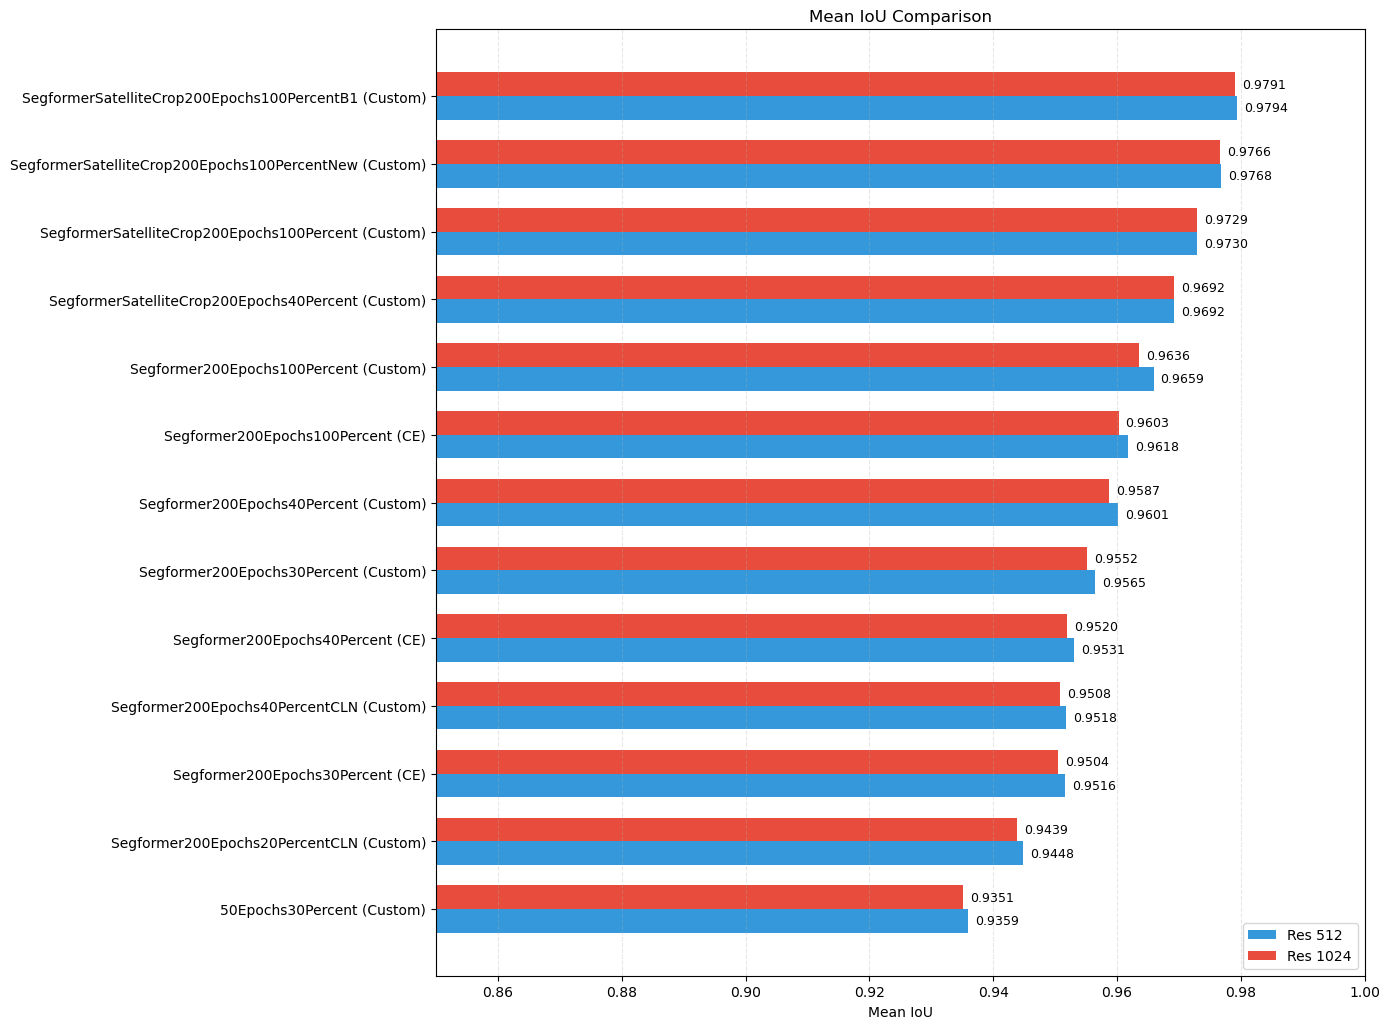

In [8]:
plot_mean_iou(df_uncropped)

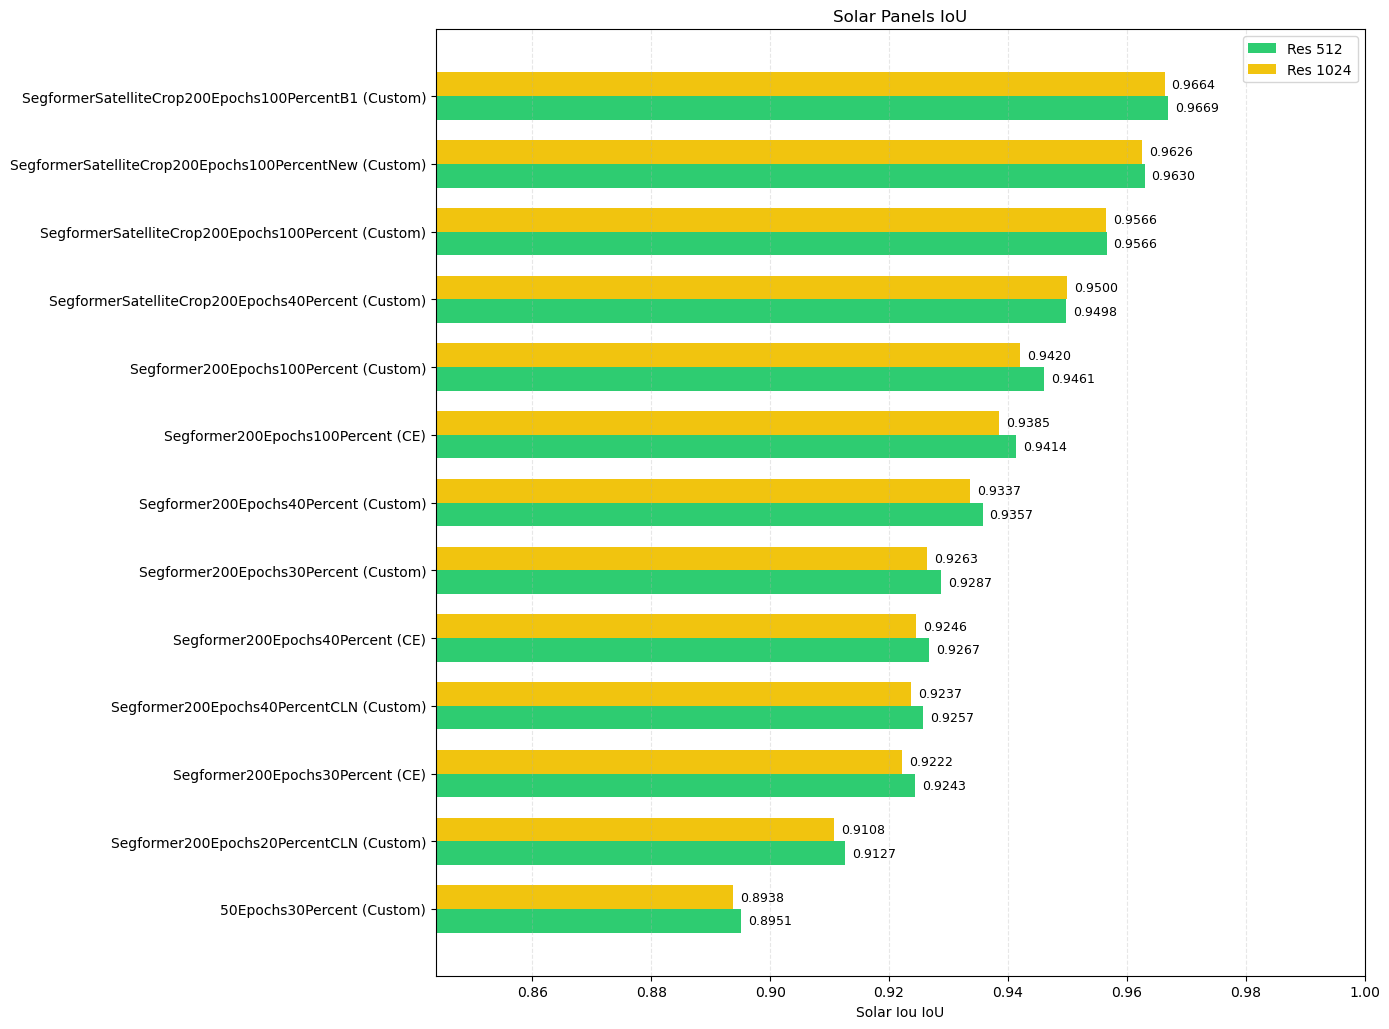

In [9]:
plot_class_iou(df_uncropped, class_prefix="solar_iou", title="Solar Panels IoU")

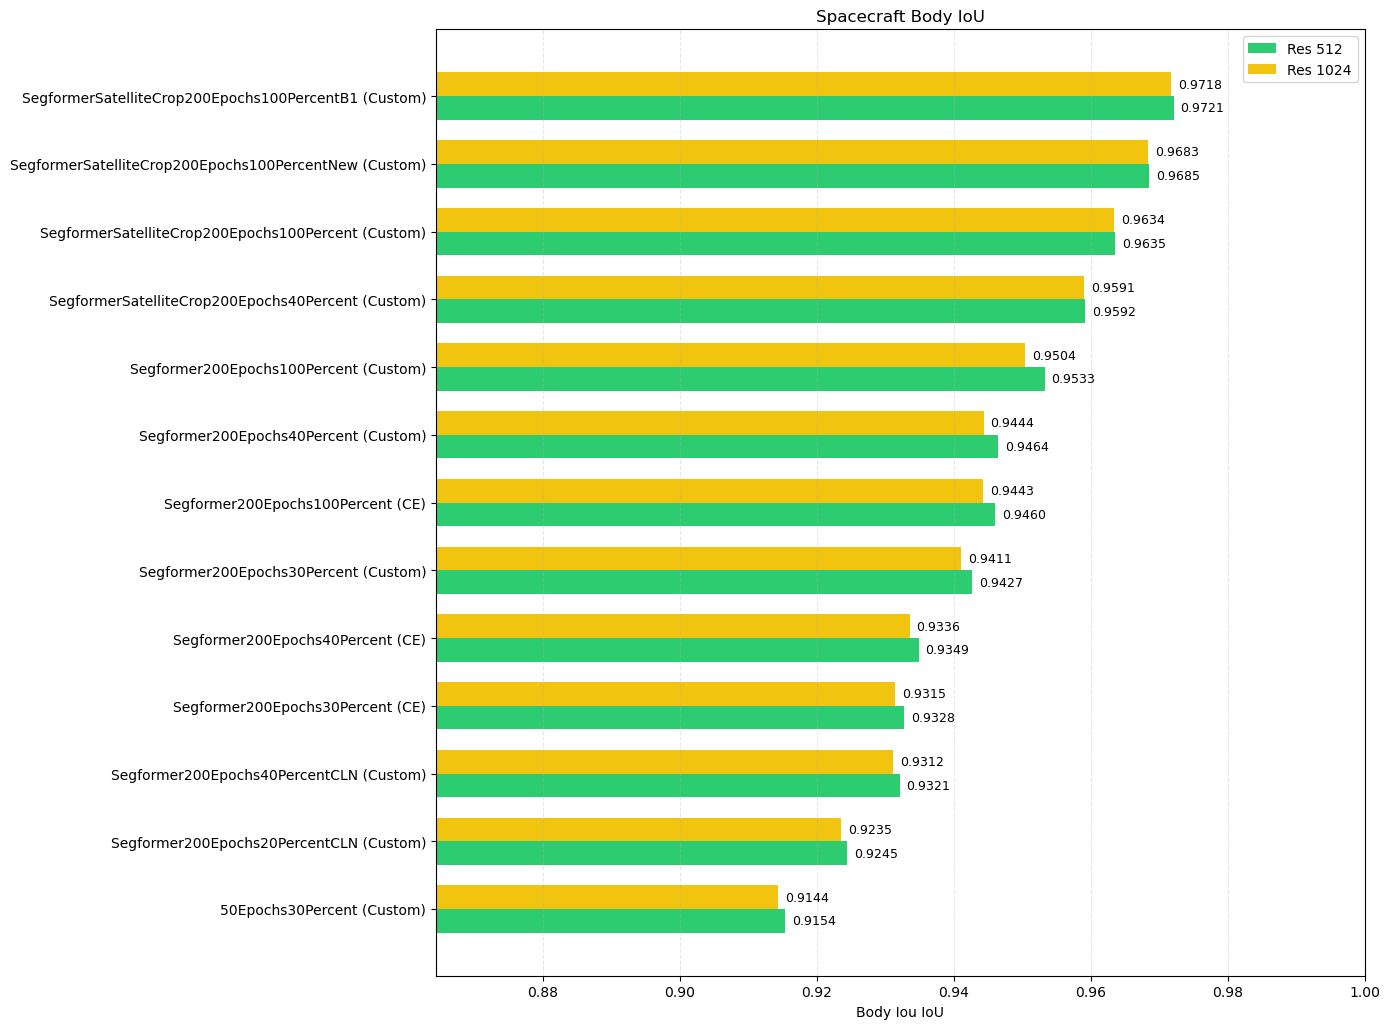

In [10]:

plot_class_iou(df_uncropped, class_prefix="body_iou", title="Spacecraft Body IoU")

## Cropped

In [11]:
df_cropped = df_segformer[df_segformer['is_cropped'] == True]

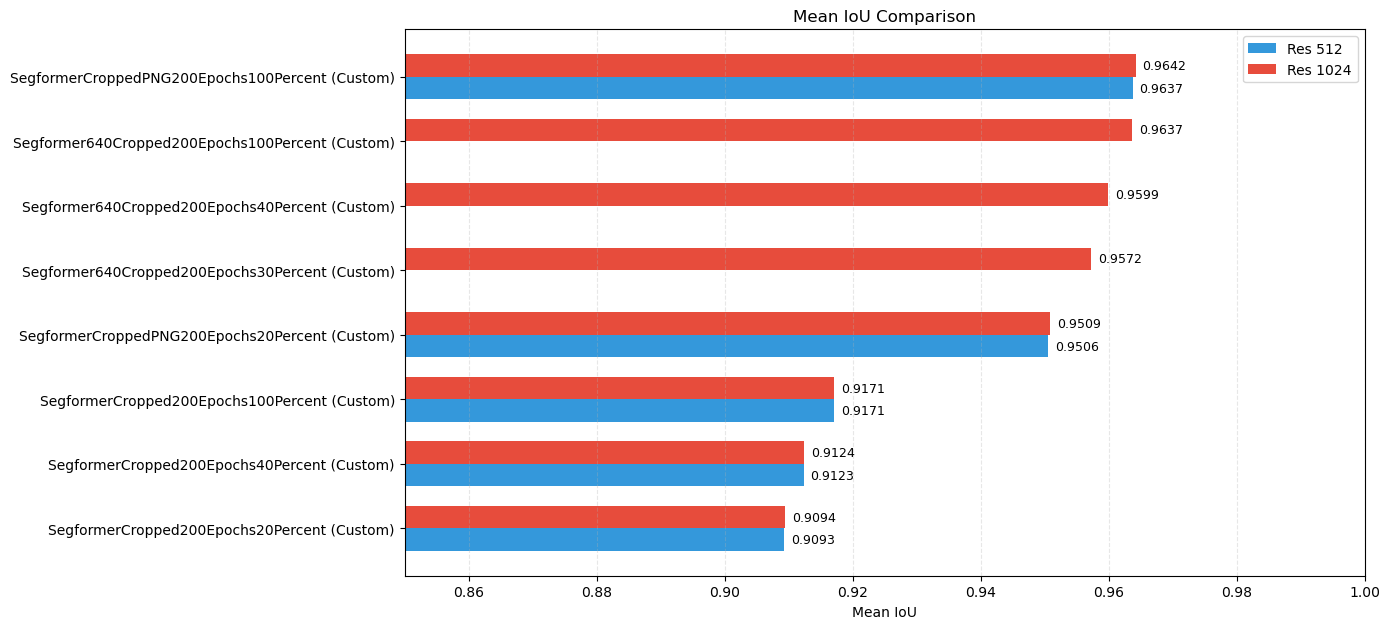

In [12]:
plot_mean_iou(df_cropped)

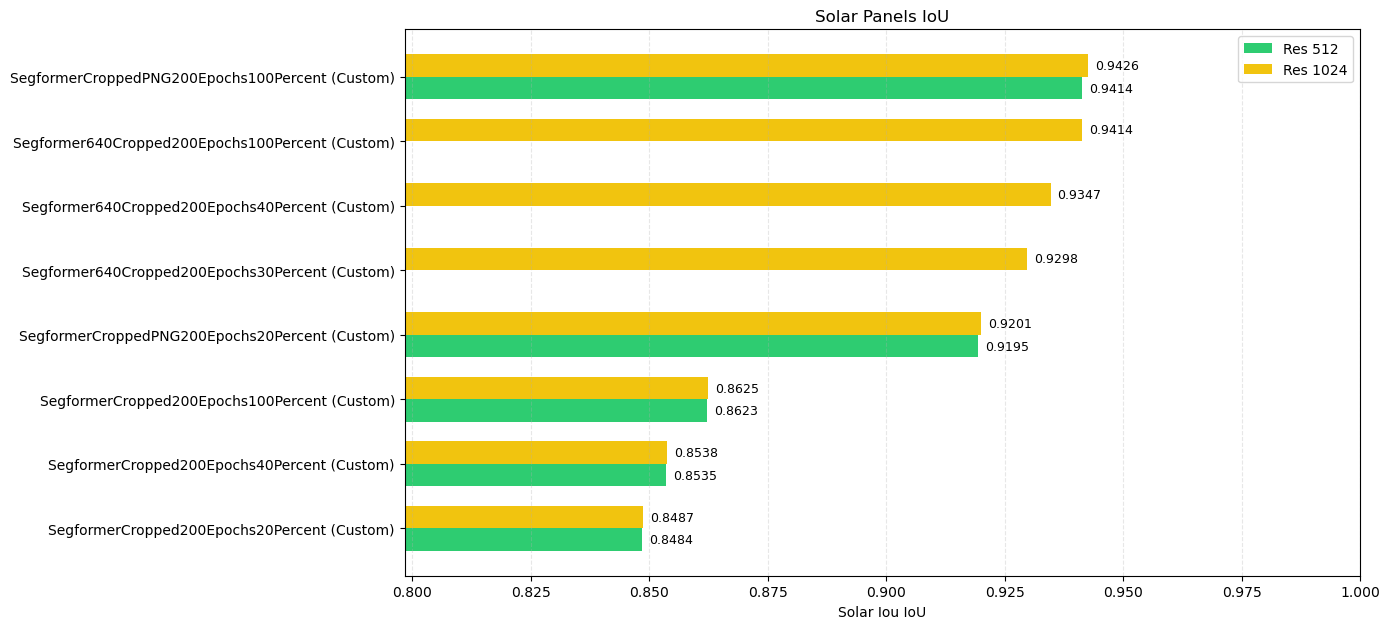

In [13]:
plot_class_iou(df_cropped, class_prefix="solar_iou", title="Solar Panels IoU")

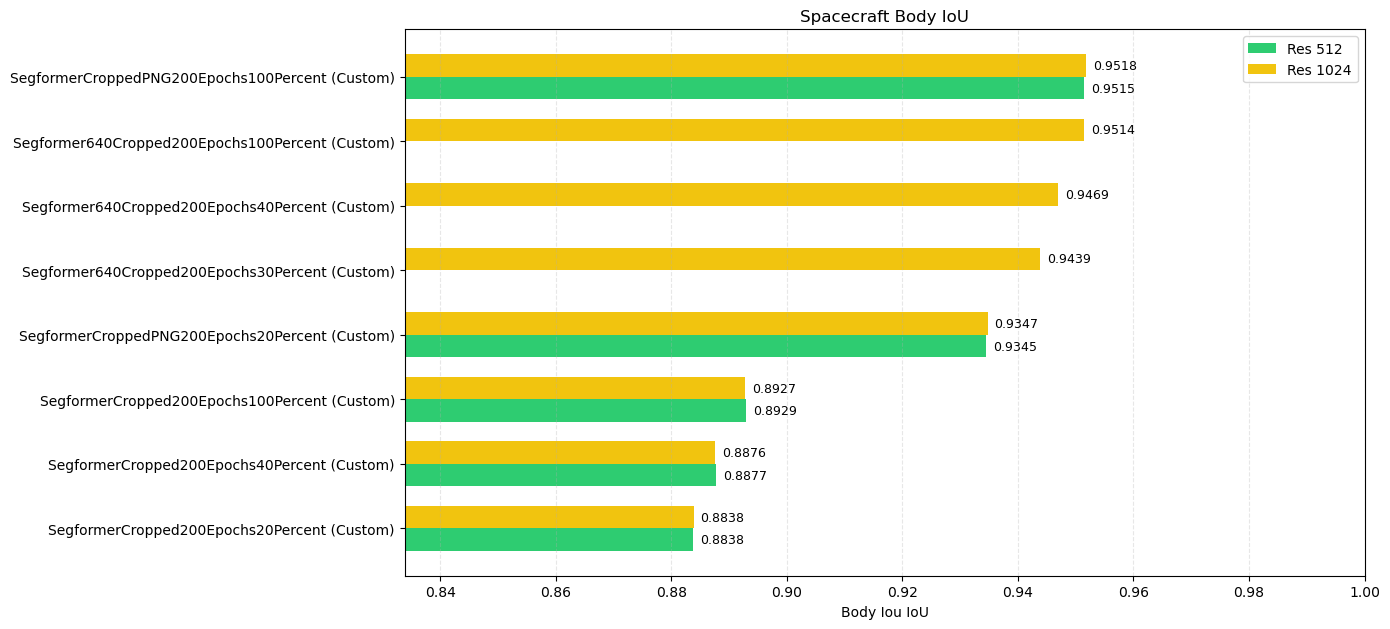

In [14]:
plot_class_iou(df_cropped, class_prefix="body_iou", title="Spacecraft Body IoU")

### Letterboxing

### Linear Crop

## Conclusion

As it's possible to see from the graphs the custom loss helps the model to perform better than the simple cross entropy loss. This is true regrdless the portion of the dataset used for the training. 
The cropping reduced the digffrence in performance between the 512x152 prediction and the full resolution prediction.
Even though the validation score is slightly lower on the test set the performances are sligtly better confirming that the cropping system helps the model to generalize better

# Unet

In [15]:
df_unet = load_experiment_results(r'..\models\segmentation\unet')

In [16]:
df_unet

,model_name,loss_type,fraction,epochs,is_cropped,mean_iou_512,body_iou_512,solar_iou_512,mean_iou_1024,body_iou_1024,solar_iou_1024
0,Unet200Epochs30Percent,CE,0.3,200,False,0.953252,0.938593,0.923247,0.951865,0.936571,0.921181
1,Unet200Epochs40Percent,CE,0.4,200,False,0.953437,0.939566,0.922772,0.951507,0.936821,0.919825
2,Unet200Epochs30Percent,CustomLoss,0.3,200,False,0.960177,0.948630,0.933569,0.958010,0.945071,0.930765
3,Unet200Epochs30PercentCLN,CustomLoss,0.3,200,False,0.952872,0.938556,0.922103,0.951144,0.936137,0.919432
4,Unet200Epochs40Percent,CustomLoss,0.4,200,False,0.961989,0.950957,0.936609,0.959581,0.947553,0.932930
5,Unet200Epochs40PercentCLN,CustomLoss,0.4,200,False,0.957301,0.943977,0.929807,0.955384,0.941078,0.927055


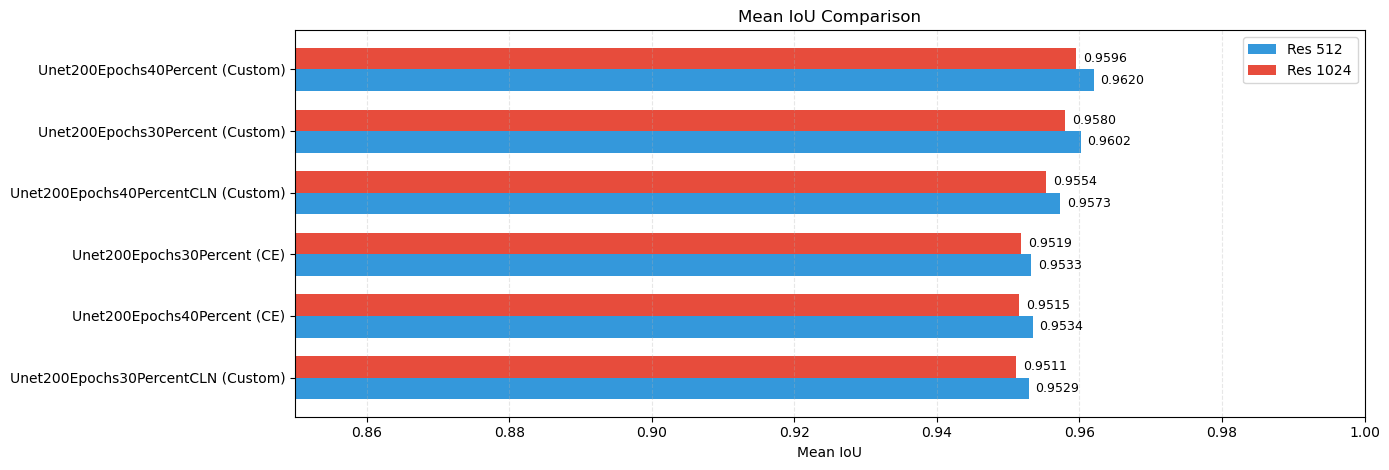

In [17]:
plot_mean_iou(df_unet)

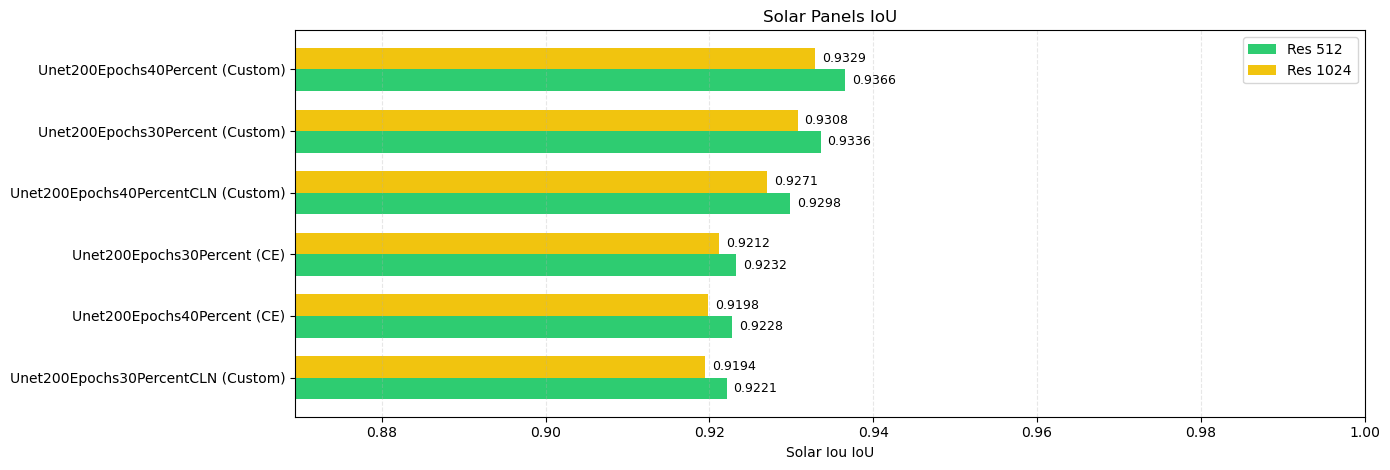

In [18]:
plot_class_iou(df_unet, class_prefix="solar_iou", title="Solar Panels IoU")

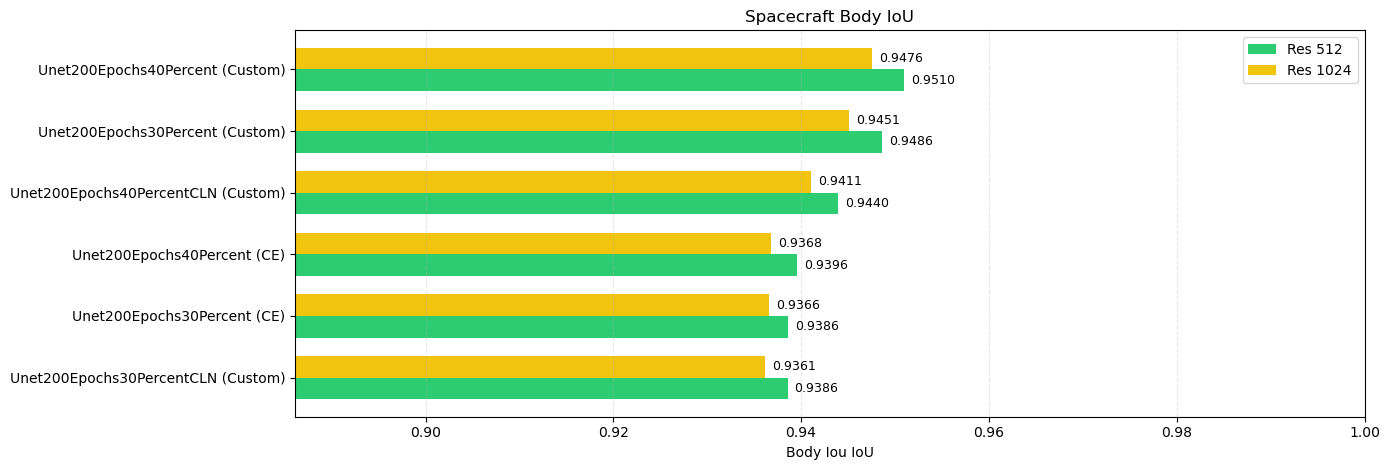

In [19]:
plot_class_iou(df_unet, class_prefix="body_iou", title="Spacecraft Body IoU")